# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from optbinning import OptimalBinning, BinningProcess, Scorecard
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, balanced_accuracy_score
from optbinning.scorecard import plot_auc_roc, plot_cap, plot_ks, ScorecardMonitoring

sns.set_theme(
    style="darkgrid",
    palette="pastel",
    font="sans-serif",
    rc={"grid.linestyle": "--", "axes.edgecolor": "0.8"}
)

pd.set_option('display.max_columns', None)

seed = 25

# 2. Dataset

In [2]:
df = pd.read_csv("data_scoring.csv")
df

,ID,Cardhldr,default,Age,Income,Exp_Inc,Avgexp,Ownrent,Selfempl,Depndt,Inc_per,Cur_add,Major,Active
0,1,1.0,0.0,27.08333,2.400,0.016798,33.0133300,0.0,0.0,0.0,2.400000,56.0,1.0,1.0
1,2,1.0,1.0,24.25000,3.500,0.069963,203.8917000,0.0,0.0,0.0,3.500000,60.0,1.0,11.0
2,3,0.0,NaN,27.41667,1.600,0.000000,0.0000000,1.0,0.0,1.0,0.800000,30.0,0.0,0.0
3,4,1.0,0.0,40.33333,3.067,0.159700,408.0825000,0.0,0.0,2.0,1.022333,18.0,0.0,0.0
4,5,1.0,0.0,28.16667,3.350,0.071625,199.3692000,1.0,0.0,0.0,3.350000,18.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1314,1315,NaN,NaN,53.25000,3.960,0.000000,0.0000000,1.0,0.0,1.0,1.980000,180.0,0.0,5.0
1315,1316,NaN,NaN,30.25000,4.506,0.000000,0.0000000,0.0,0.0,2.0,1.502000,38.0,1.0,7.0
1316,1317,NaN,NaN,27.91667,3.960,0.000000,0.0000000,0.0,0.0,2.0,1.320000,7.0,1.0,5.0
1317,1318,NaN,NaN,46.41667,3.500,0.000000,0.0000000,1.0,0.0,1.0,1.750000,121.0,0.0,5.0


In [3]:
accepted = df[df['Cardhldr'] == 1]
rejected = df[df['Cardhldr'] == 0]
new_clients = df[df['Cardhldr'].isna()]

print("Accepted:", accepted.shape)
print("Rejected:", rejected.shape)
print("New clients:", new_clients.shape)

Accepted: (994, 14)
Rejected: (291, 14)
New clients: (34, 14)


# 3. EDA

In [4]:
accepted.info()

<class 'pandas.DataFrame'>
Index: 994 entries, 0 to 1284
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        994 non-null    int64  
 1   Cardhldr  994 non-null    float64
 2   default   994 non-null    float64
 3   Age       994 non-null    float64
 4   Income    994 non-null    float64
 5   Exp_Inc   994 non-null    float64
 6   Avgexp    994 non-null    str    
 7   Ownrent   994 non-null    float64
 8   Selfempl  994 non-null    float64
 9   Depndt    994 non-null    float64
 10  Inc_per   994 non-null    float64
 11  Cur_add   994 non-null    float64
 12  Major     994 non-null    float64
 13  Active    994 non-null    float64
dtypes: float64(12), int64(1), str(1)
memory usage: 116.5 KB


In [5]:
# Transform Avgexp to float64
for df in [accepted, rejected, new_clients]:
    df['Avgexp'] = pd.to_numeric(
        df['Avgexp'].str.replace(',', '', regex=False)
    )

## Missing values

In [6]:
print("Accepted:\n", accepted.isna().sum())
print("Rejected:\n", rejected.isna().sum())
print("New clients:\n", new_clients.isna().sum())

Accepted:
 ID          0
Cardhldr    0
default     0
Age         0
Income      0
Exp_Inc     0
Avgexp      0
Ownrent     0
Selfempl    0
Depndt      0
Inc_per     0
Cur_add     0
Major       0
Active      0
dtype: int64
Rejected:
 ID            0
Cardhldr      0
default     291
Age           0
Income        0
Exp_Inc       0
Avgexp        0
Ownrent       0
Selfempl      0
Depndt        0
Inc_per       0
Cur_add       0
Major         0
Active        0
dtype: int64
New clients:
 ID           0
Cardhldr    34
default     34
Age          0
Income       0
Exp_Inc      0
Avgexp       0
Ownrent      0
Selfempl     0
Depndt       0
Inc_per      0
Cur_add      0
Major        0
Active       0
dtype: int64


> There are **no missing values** in this dataset

## Target

In [7]:
accepted.default.value_counts()

default
0.0    890
1.0    104
Name: count, dtype: int64

In [8]:
accepted.default.value_counts(normalize=True)

default
0.0    0.895372
1.0    0.104628
Name: proportion, dtype: float64

In [9]:
yT_0 = accepted.default.value_counts(normalize=True)[0]
yT_1 = accepted.default.value_counts(normalize=True)[1]

> The target variable is **imbalanced**, with 89.54% of customers not defaulting and only 10.46% defaulting.

## Features

In [10]:
accepted.drop(columns=['ID', 'Cardhldr', 'default']).describe()

,Age,Income,Exp_Inc,Avgexp,Ownrent,Selfempl,Depndt,Inc_per,Cur_add,Major,Active
count,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000
mean,33.188715,3.447242,0.089110,239.612725,0.479879,0.061368,0.973843,2.214605,54.691147,0.841046,7.265594
std,10.180138,1.716888,0.099877,289.158901,0.499846,0.240125,1.250708,1.355279,64.671143,0.365817,6.074552
min,0.166670,0.210000,0.000186,0.000000,0.000000,0.000000,0.000000,0.070000,0.000000,0.000000,0.000000
25%,25.333330,2.313625,0.026912,66.823750,0.000000,0.000000,0.000000,1.250000,12.000000,1.000000,2.000000
50%,31.000000,3.000000,0.060319,150.540850,0.000000,0.000000,0.000000,1.970667,28.000000,1.000000,6.000000
75%,39.729168,4.000000,0.114712,315.023975,1.000000,0.000000,2.000000,2.797500,72.000000,1.000000,11.000000
max,83.500000,13.500000,0.906320,3099.505000,1.000000,1.000000,6.000000,10.999900,540.000000,1.000000,31.000000


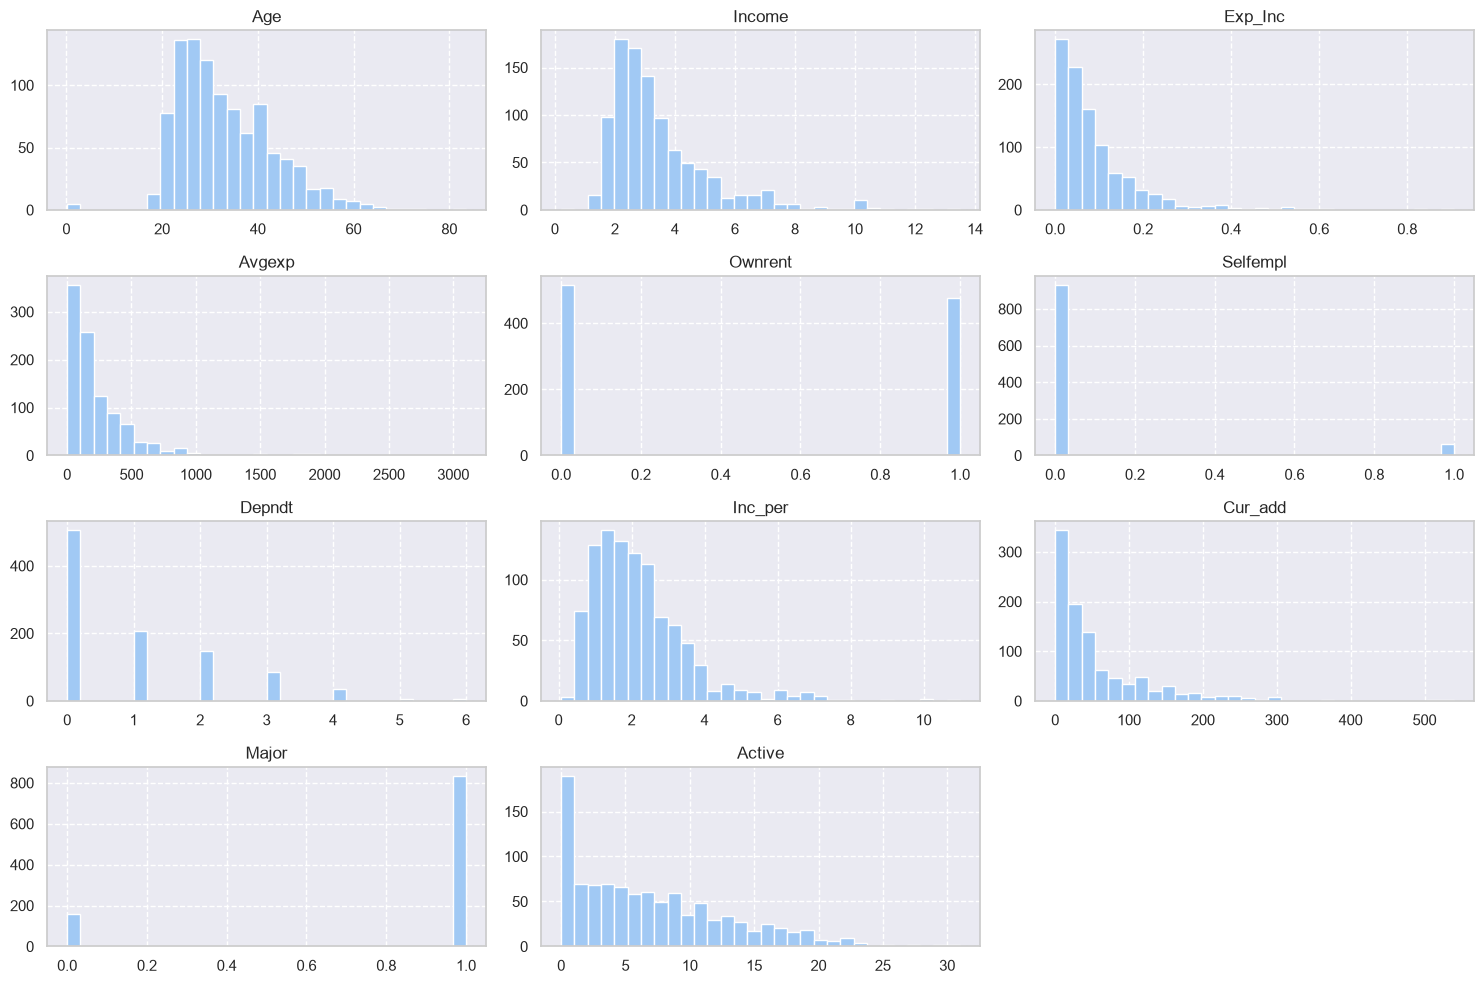

In [11]:
accepted.drop(columns=['ID', 'Cardhldr', 'default']).hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

### Age

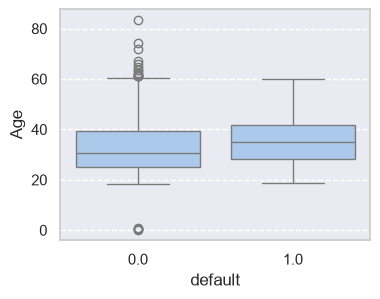

In [12]:
plt.figure(figsize=(4,3))
sns.boxplot(data=accepted, x='default', y='Age')
plt.show()

In [13]:
accepted.groupby('default')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0.0,890.0,32.868446,10.174212,0.16667,25.16667,30.625000,39.479168,83.50000
1.0,104.0,35.929487,9.859584,18.66667,28.43750,35.166665,41.874997,60.08333


In [14]:
accepted[accepted['Age'] < 18]

,ID,Cardhldr,default,Age,Income,Exp_Inc,Avgexp,Ownrent,Selfempl,Depndt,Inc_per,Cur_add,Major,Active
433,434,1.0,0.0,0.58333,2.50,0.083171,173.0233,0.0,0.0,0.0,2.500,150.0,1.0,5.0
472,473,1.0,0.0,0.16667,3.24,0.184366,497.7058,1.0,0.0,3.0,0.810,25.0,1.0,16.0
564,565,1.0,0.0,0.58333,4.00,0.072664,242.1283,1.0,0.0,3.0,1.000,24.0,1.0,4.0
1139,1140,1.0,0.0,0.75000,1.60,0.154191,205.2542,0.0,0.0,0.0,1.600,1.0,1.0,9.0
1172,1173,1.0,0.0,0.50000,3.05,0.101724,258.5492,0.0,0.0,1.0,1.525,94.0,1.0,5.0


> **`Age`** presents five values below 18 years, all corresponding to customers with no default. Since these values are not plausible in the context of credit card applicants, they are considered anomalous values and will need to be addressed before model training.

### Income

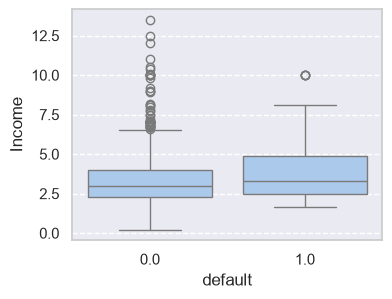

In [15]:
plt.figure(figsize=(4,3))
sns.boxplot(data=accepted, x='default', y='Income')
plt.show()

In [16]:
accepted.groupby('default')['Income'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0.0,890.0,3.382953,1.658807,0.21,2.3,2.9800,4.00,13.500
1.0,104.0,3.997411,2.080200,1.66,2.5,3.3025,4.85,10.032


> **`Income`** is higher on average among customers who defaulted. The mean income is 3.38 for non-defaulted customers compared to 4.00 for defaulted customers. The median and upper quartile show the same pattern.

### Exp_Inc

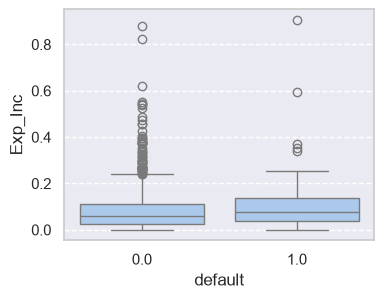

In [17]:
plt.figure(figsize=(4,3))
sns.boxplot(data=accepted, x='default', y='Exp_Inc')
plt.show()

In [18]:
accepted.groupby('default')['Exp_Inc'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0.0,890.0,0.087110,0.096980,0.000186,0.025412,0.059321,0.111950,0.877846
1.0,104.0,0.106223,0.121094,0.000444,0.036319,0.077309,0.138797,0.906320


In [19]:
rejected.Exp_Inc.value_counts()

Exp_Inc
0.0    291
Name: count, dtype: int64

> **`Exp_Inc`** is higher among customers who defaulted, with both the mean and median being higher than for non-defaulted customers. This suggests that customers with higher credit card expenditure relative to their income may present a higher risk of default. On the other hand, rejected applicants never held a card, so the variable is structurally zero.

### Avgexp

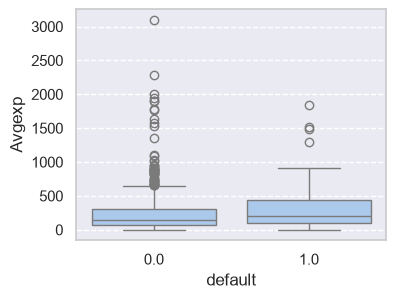

In [20]:
plt.figure(figsize=(4,3))
sns.boxplot(data=accepted, x='default', y='Avgexp')
plt.show()

In [21]:
accepted.groupby('default')['Avgexp'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0.0,890.0,229.784801,282.402666,0.0,63.642920,146.88040,301.99815,3099.505
1.0,104.0,323.717071,331.327032,0.0,93.386453,206.86795,444.09415,1836.976


In [22]:
rejected.Avgexp.value_counts()

Avgexp
0.0    291
Name: count, dtype: int64

> **`Avgexp`** is higher among customers who defaulted, with both the mean and median being substantially higher than for non-defaulted customers. This suggests that higher average monthly credit card expenditure may be associated with a greater risk of default. The variable is right-skewed and contains some high values, but no obvious data errors were identified. As Exp_Inc, this variable is zero for rejected clients, including them would bias the reject-inference step, pushing every rejected applicant into the safest WOE bin by construction rather than by actual risk. Therefore, Avgexp and Exp_Inc will be excluded from the model.

### Ownrent

accepted.Ownrent.value_counts(normalize=True)

In [23]:
accepted.groupby('Ownrent')['default'].agg(['count', 'mean'])

,count,mean
Ownrent,,
0.0,517,0.094778
1.0,477,0.115304


> **`Ownrent`** is relatively balanced, with 52.01% of customers renting and 47.99% owning their home. The default rate is slightly higher among homeowners (11.53%) than among renters (9.48%). However, the difference is relatively small, suggesting that Ownrent may have limited discriminative power on its own.

### Selfempl

In [24]:
accepted.Selfempl.value_counts(normalize=True)

Selfempl
0.0    0.938632
1.0    0.061368
Name: proportion, dtype: float64

In [25]:
accepted.groupby('Selfempl')['default'].agg(['count', 'mean'])

,count,mean
Selfempl,,
0.0,933,0.101822
1.0,61,0.147541


> **`Selfempl`** is highly imbalanced, with only 6.14% of customers being self-employed. The default rate is higher among self-employed customers (14.75%) compared to non-self-employed customers (10.18%). However, this difference should be interpreted with caution due to the relatively small number of self-employed customers.

### Depndt

In [26]:
accepted.groupby('default')['Depndt'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0.0,890.0,0.970787,1.245573,0.0,0.0,0.0,2.0,6.0
1.0,104.0,1.000000,1.299739,0.0,0.0,0.0,2.0,6.0


In [27]:
accepted.groupby('Depndt')['default'].agg(['count', 'mean'])

,count,mean
Depndt,,
0.0,506,0.104743
1.0,206,0.101942
2.0,148,0.094595
3.0,87,0.137931
4.0,35,0.057143
5.0,7,0.142857
6.0,5,0.200000


> **`Depndt`** does not show a clear or consistent relationship with default risk. Default rates vary across the different numbers of dependents, but there is no clear monotonic trend. The higher default rates observed for customers with five or six dependents are based on very few observations and should therefore be interpreted with caution.

### Inc_per

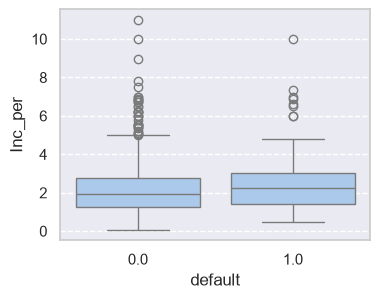

In [28]:
plt.figure(figsize=(4,3))
sns.boxplot(data=accepted, x='default', y='Inc_per')
plt.show()

In [29]:
accepted.groupby('default')['Inc_per'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0.0,890.0,2.176171,1.313817,0.07,1.237500,1.930,2.748525,10.9999
1.0,104.0,2.543511,1.639445,0.50,1.426893,2.225,3.012500,9.9999


> **`Inc_per`** is higher among customers who defaulted, with higher mean, median, and third-quartile values compared to non-defaulted customers. This suggests a potential positive relationship between income per dependent and default risk in this dataset.

### Cur_add

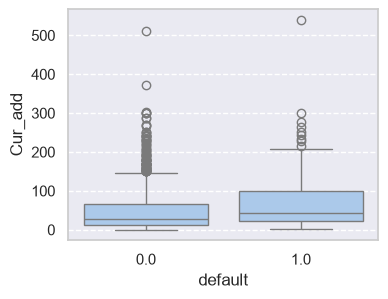

In [30]:
plt.figure(figsize=(4,3))
sns.boxplot(data=accepted, x='default', y='Cur_add')
plt.show()

In [31]:
accepted.groupby('default')['Cur_add'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0.0,890.0,52.252809,61.568476,0.0,12.0,27.0,67.0,511.0
1.0,104.0,75.557692,84.335993,3.0,23.5,44.0,99.0,540.0


> **`Cur_add`** is considerably higher among customers who defaulted. Defaulted customers show higher mean, median, and quartile values, indicating that they tend to have lived longer at their current address. The variable also shows substantial dispersion and right skewness, with some customers reporting very long periods at the same address.

### Major

In [32]:
accepted.Major.value_counts(normalize=True)

Major
1.0    0.841046
0.0    0.158954
Name: proportion, dtype: float64

In [33]:
accepted.groupby('Major')['default'].agg(['count', 'mean'])

,count,mean
Major,,
0.0,158,0.069620
1.0,836,0.111244


> **`Major`** highly imbalanced, with 84.10% of customers having one major credit card and 15.90% having none. Customers with one major credit card show a higher default rate (11.12%) compared to those with none (6.96%). This suggests a potential relationship between Major and default risk, although the imbalance between the two categories should be taken into account.

### Active

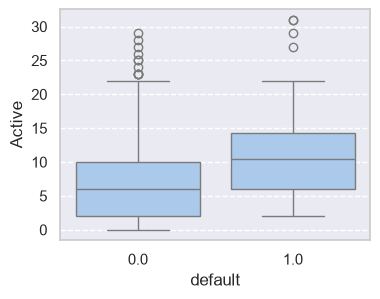

In [34]:
plt.figure(figsize=(4,3))
sns.boxplot(data=accepted, x='default', y='Active')
plt.show()

In [35]:
accepted.groupby('default')['Active'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0.0,890.0,6.816854,5.874881,0.0,2.0,6.0,10.00,29.0
1.0,104.0,11.105769,6.420414,2.0,6.0,10.5,14.25,31.0


> **`Active`** is considerably higher among customers who defaulted. Defaulted customers have higher mean, median, and quartile values, indicating that they tend to have a greater number of active credit accounts. The difference is particularly noticeable in the mean (6.82 vs. 11.11) and median (6.0 vs. 10.5), suggesting a potentially strong relationship between the number of active credit accounts and default risk.

# 4. Preprocessing

## Tranform invalid ages into NaN

In [36]:
accepted.loc[accepted['Age'] < 18, 'Age'] = np.nan
rejected.loc[rejected['Age'] < 18, 'Age'] = np.nan
new_clients.loc[new_clients['Age'] < 18, 'Age'] = np.nan

## Train / test split

In [37]:
accepted_train, accepted_test = train_test_split(
    accepted, 
    stratify=accepted["default"], 
    test_size=.2, 
    random_state=seed)

In [38]:
print(accepted_train.default.shape)
print(accepted_train.default.mean())

(795,)
0.10440251572327044


In [39]:
print(accepted_test.default.shape)
print(accepted_test.default.mean())

(199,)
0.10552763819095477


## Impute misssing values

In [40]:
age_median = accepted_train['Age'].median()

accepted_train['Age'] = accepted_train['Age'].fillna(age_median)
accepted_test['Age'] = accepted_test['Age'].fillna(age_median)
rejected['Age'] = rejected['Age'].fillna(age_median)
new_clients['Age'] = new_clients['Age'].fillna(age_median)

## Binning

In [41]:
target = 'default'
categorical_cols = ['Ownrent', 'Selfempl', 'Depndt', 'Major']
numerical_cols = ['Age', 'Income', 'Inc_per', 'Cur_add', 'Active']

In [42]:
Y = accepted_train['default'].values
X = accepted_train.drop(columns=['default', 'ID', 'Cardhldr', 'Exp_Inc', 'Avgexp'])
list_variables = X.columns.values.tolist()

binning_process = BinningProcess(
    min_bin_size=0.10,
    max_n_bins=5,
    special_codes=None,
    categorical_variables=categorical_cols,
    variable_names=list_variables,
    selection_criteria={"iv": {"min": 0.02}}
)

accepted_train_binned = binning_process.fit(X, Y)
accepted_train_binned.summary().sort_values('iv')

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
3,Selfempl,categorical,OPTIMAL,False,1,0.0,0.0,0,0.0
2,Ownrent,categorical,OPTIMAL,False,2,0.013854,0.001731,0.058803,0.026429
4,Depndt,categorical,OPTIMAL,True,3,0.025797,0.003217,0.078212,0.014263
7,Major,categorical,OPTIMAL,True,2,0.028112,0.003491,0.057297,0.034393
1,Income,numerical,OPTIMAL,True,4,0.084626,0.010468,0.150687,0.049674
5,Inc_per,numerical,OPTIMAL,True,4,0.158284,0.018868,0.161703,0.164432
6,Cur_add,numerical,OPTIMAL,True,5,0.185961,0.022957,0.2312,0.017298
0,Age,numerical,OPTIMAL,True,5,0.186075,0.022899,0.226428,0.002467
8,Active,numerical,OPTIMAL,True,5,0.854258,0.089798,0.388859,0.132673


# 5. Model

## First model: only accepted

In [43]:
estimator = LogisticRegression(solver="lbfgs", penalty="l2")

scorecard = Scorecard(binning_process=binning_process,
                   estimator=estimator,
                   scaling_method="pdo_odds",
                   scaling_method_params={"pdo":40, "odds": 50, "scorecard_points": 600})

scorecard.fit(X, Y, show_digits=4)

C:\Users\zaida\anaconda3\envs\scoring_model\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,binning_process,"BinningProces...r', 'Active'])"
,estimator,LogisticRegre...(penalty='l2')
,scaling_method,'pdo_odds'
,scaling_method_params,"{'odds': 50, 'pdo': 40, 'scorecard_points': 600}"
,intercept_based,False
,reverse_scorecard,False
,rounding,False
,verbose,False
Name,Type,Value
binning_process_,BinningProcess,"BinningProces...r', 'Active'])"
estimator_,LogisticRegression,LogisticRegre...(penalty='l2')


In [44]:
Y_pred=scorecard.predict_proba(X)[:,1]
Y_pred.mean().round(5)

np.float64(0.10444)

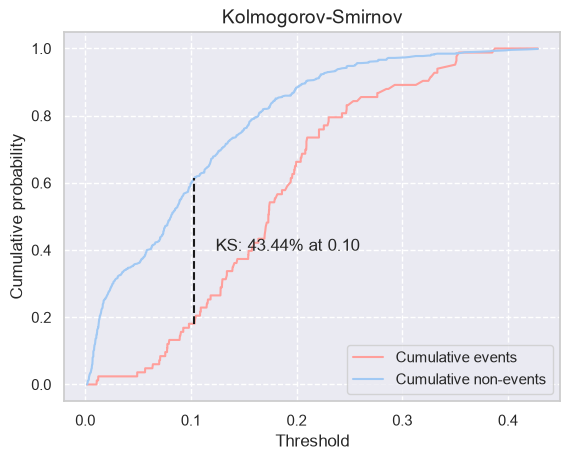

In [45]:
plot_ks(Y, Y_pred)

F1_score cutoff:  0.17
F1_score max  0.359


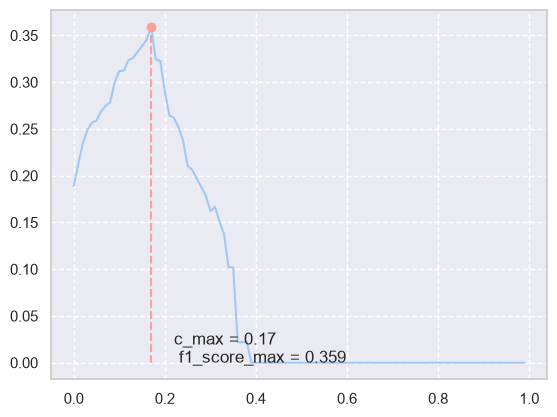

In [46]:
c=np.arange(0,1,0.01)
f1_score_ = [f1_score(accepted_train["default"],np.multiply(Y_pred>c_,1)) for c_ in c]
c_max = c[np.argmax(f1_score_)]
print("F1_score cutoff: ", c_max)
print("F1_score max ", np.max(f1_score_).round(3))

plt.plot(c,f1_score_)
plt.stem(c_max, np.max(f1_score_),linefmt='r--', markerfmt='ro', basefmt='r--')
plt.text(c_max+0.05, 0, "c_max = "+str(c_max.round(2))+"\n f1_score_max = "+str(np.max(f1_score_).round(3)))
plt.show()

c_maxF1=c_max

Youden cutoff:  0.1
Youden max 0.419


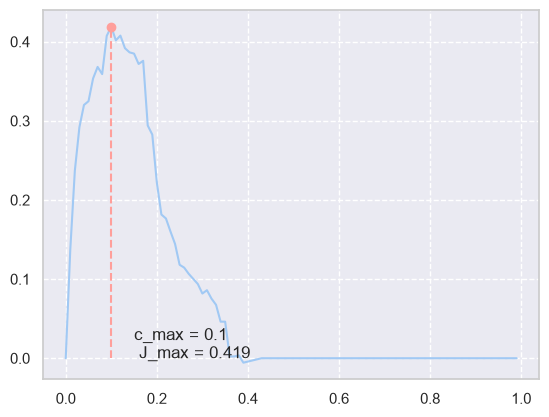

In [47]:
J= [balanced_accuracy_score(accepted_train["default"],np.multiply(Y_pred>c_,1), adjusted=True) for c_ in c ]
c_max = c[np.argmax(J)]
print("Youden cutoff: ", c_max)
print("Youden max", np.max(J).round(3))

plt.plot(c,J)
plt.stem(c_max, np.max(J),linefmt='r--', markerfmt='ro', basefmt='r--')
plt.text(c_max+0.05, 0, "c_max = "+str(c_max.round(2))+"\n J_max = "+str(np.max(J).round(3)))
plt.show()

In [48]:
Prob_Cutoff=Y.mean()
print('Cutoff selected:', Prob_Cutoff.round(2),'\n'
      'Mean event frequency (y=1):', Y.mean().round(2), '\n'
      'Max F1-score :', c_maxF1)

Cutoff selected: 0.1 
Mean event frequency (y=1): 0.1 
Max F1-score : 0.17


In [49]:
accepted_train["default_pred"]=np.multiply(Y_pred>Prob_Cutoff,1)
tab=pd.crosstab(accepted_train["default"],accepted_train["default_pred"],margins=True, normalize="all").round(3)
print(tab)
print("Accuracy:", (tab.iloc[1,1]+tab.iloc[0,0]).round(3))

default_pred      0      1    All
default                          
0.0           0.553  0.342  0.896
1.0           0.020  0.084  0.104
All           0.574  0.426  1.000
Accuracy: 0.637


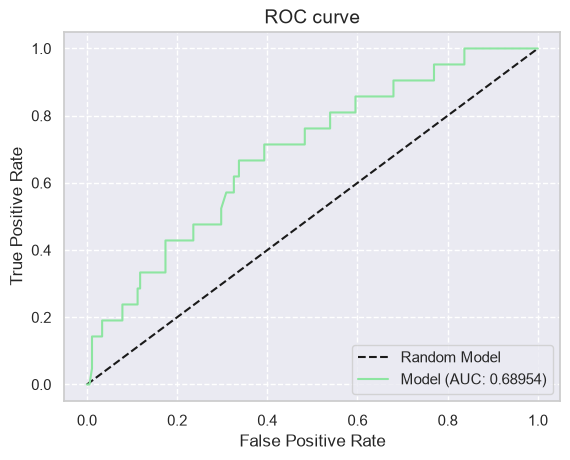

In [50]:
Y_test = accepted_test['default'].values
X_test = accepted_test.drop(columns=['default', 'ID', 'Cardhldr'])

Y_test_pred=scorecard.predict_proba(X_test)[:,1]

plot_auc_roc(Y_test,Y_test_pred)

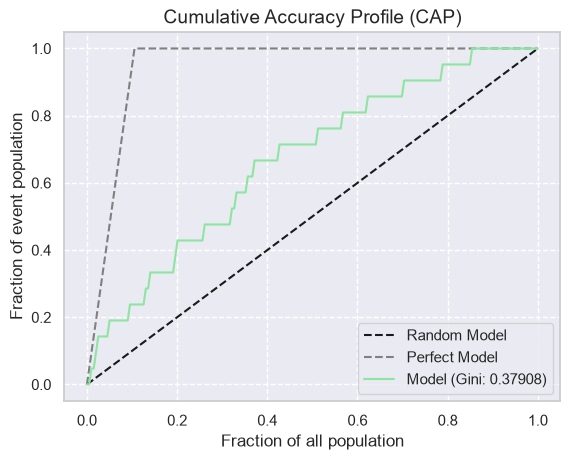

In [51]:
plot_cap(Y_test,Y_test_pred)

In [52]:
score = scorecard.score(X)
print("Min Score: ", score.min().round(2))
print("Max Score: ",score.max().round(2))
print("Mean Score : ",score.mean().round(2))

Min Score:  390.91
Max Score:  744.66
Mean Score :  529.38


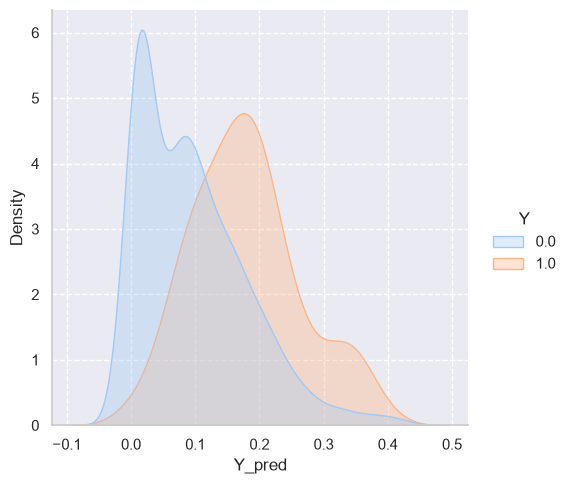

In [53]:
data_score=pd.DataFrame(np.transpose([Y_pred,Y]), columns=['Y_pred','Y'])
sns.displot(data=data_score, x='Y_pred', label="event", hue='Y', alpha=0.35,kind="kde", fill=True, common_norm=False)
plt.show()

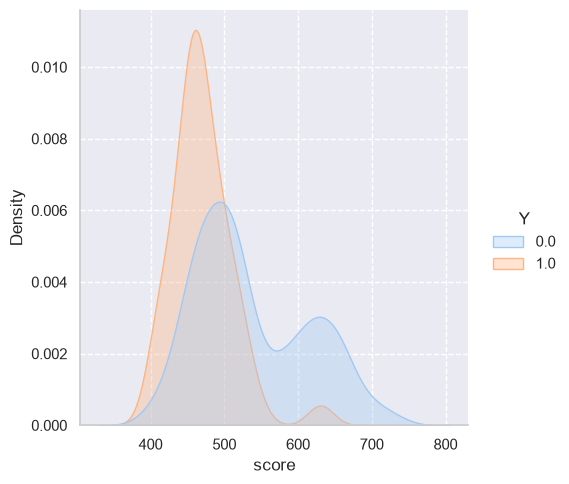

In [54]:
data_score=pd.DataFrame(np.transpose([score,Y]), columns=['score','Y'])
sns.displot(data=data_score, x='score', label="event", hue='Y', alpha=0.35,kind="kde", fill=True, common_norm=False)
plt.show()

## Second model: add rejected inference

In [55]:
c=np.arange(0,1,0.01)
f1_score_ = [f1_score(accepted_train["default"],np.multiply(Y_pred>c_,1)) for c_ in c]
c_max = c[np.argmax(f1_score_)]
print("Cutoff for max f1 score: ", c_max)
print("Max f1 score ", np.max(f1_score_).round(3))

Cutoff for max f1 score:  0.17
Max f1 score  0.359


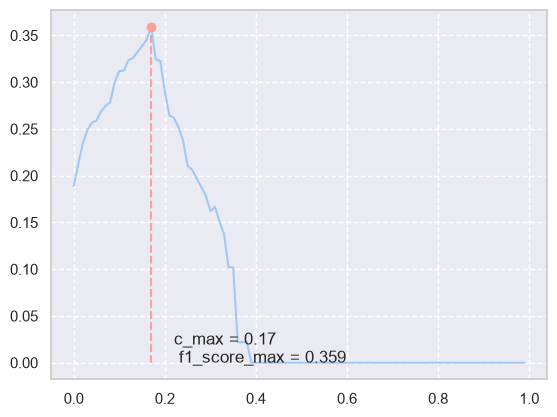

In [56]:
plt.plot(c,f1_score_)
plt.stem(c_max, np.max(f1_score_),linefmt='r--', markerfmt='ro', basefmt='r--')
plt.text(c_max+0.05, 0, "c_max = "+str(c_max.round(2))+"\n f1_score_max = "+str(np.max(f1_score_).round(3)))
plt.show()

c_maxF1=c_max

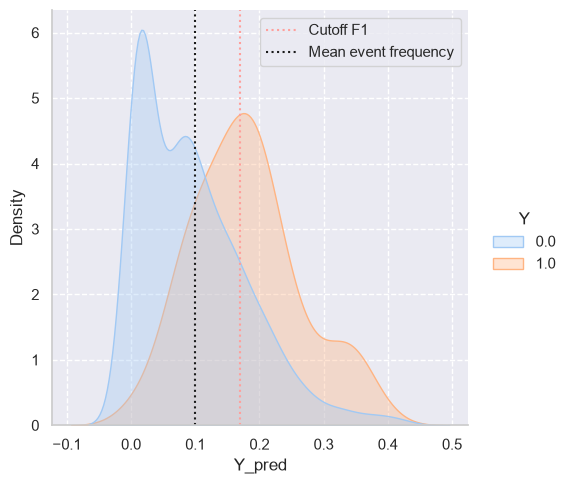

In [57]:
data_score=pd.DataFrame(np.transpose([Y_pred,Y]), columns=['Y_pred','Y'])
sns.displot(data=data_score, x='Y_pred', hue='Y', alpha=0.35,kind="kde", fill=True, common_norm=False)
plt.axvline(c_maxF1, color='r', linestyle=":", label="Cutoff F1")
plt.axvline(round(Y.mean(),2), color='k', linestyle=":", label="Mean event frequency")
plt.legend()

In [58]:
Prob_Cutoff=c_maxF1

print('Selected Cutoff:', Prob_Cutoff,'\n'
      'Mean event frequency (y=1):', round(Y.mean(),2), '\n'
      'Prob for max F1 score:', c_maxF1, '\n'
      'Max f1 score', np.max(f1_score_).round(3))

Selected Cutoff: 0.17 
Mean event frequency (y=1): 0.1 
Prob for max F1 score: 0.17 
Max f1 score 0.359


In [59]:
X_rejected = rejected.drop(columns=['default']) 
Y_rejected_pred=scorecard.predict_proba(X_rejected)[:,1] 
rejected["default"]=np.multiply(Y_rejected_pred>Prob_Cutoff,1)

In [60]:
rejected.default.value_counts(normalize=True)

default
0    0.835052
1    0.164948
Name: proportion, dtype: float64

In [61]:
X_new = new_clients.drop(columns=['default'])
Y_new_pred=scorecard.predict_proba(X_new)[:,1]
new_clients["Prob_without_rejected"]=np.multiply(Y_new_pred,1)
new_clients["y_without_rejected"]=np.multiply(Y_new_pred>Prob_Cutoff,1)

In [62]:
df = pd.concat([accepted, rejected], axis=0)
df.info()
print("\n",df.default.value_counts(normalize=True))

<class 'pandas.DataFrame'>
Index: 1285 entries, 0 to 1281
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        1285 non-null   int64  
 1   Cardhldr  1285 non-null   float64
 2   default   1285 non-null   float64
 3   Age       1280 non-null   float64
 4   Income    1285 non-null   float64
 5   Exp_Inc   1285 non-null   float64
 6   Avgexp    1285 non-null   float64
 7   Ownrent   1285 non-null   float64
 8   Selfempl  1285 non-null   float64
 9   Depndt    1285 non-null   float64
 10  Inc_per   1285 non-null   float64
 11  Cur_add   1285 non-null   float64
 12  Major     1285 non-null   float64
 13  Active    1285 non-null   float64
dtypes: float64(13), int64(1)
memory usage: 150.6 KB

 default
0.0    0.881712
1.0    0.118288
Name: proportion, dtype: float64


In [63]:
df_train, df_test = train_test_split(df, stratify=df['default'], test_size=.25, random_state=seed)
print(df_train['default'].mean(), df_test['default'].mean())

0.11838006230529595 0.11801242236024845


In [64]:
Y = df_train['default'].values
X = df_train.drop(columns=['default', 'ID', 'Cardhldr', 'Exp_Inc', 'Avgexp'])
list_variables = X.columns.values.tolist()

binning_process = BinningProcess(
    min_bin_size=0.10,
    max_n_bins=5,
    special_codes=None,
    categorical_variables=categorical_cols,
    variable_names=list_variables,
    selection_criteria={"iv": {"min": 0.02}}
)

df_train_binned = binning_process.fit(X, Y)
df_train_binned.summary().sort_values('iv')

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
3,Selfempl,categorical,OPTIMAL,False,1,0.0,0.0,0,0.0
4,Depndt,categorical,OPTIMAL,True,4,0.034209,0.004258,0.095603,0.011187
7,Major,categorical,OPTIMAL,True,2,0.034272,0.004253,0.064999,0.049348
2,Ownrent,categorical,OPTIMAL,True,2,0.07338,0.009144,0.13502,0.196406
1,Income,numerical,OPTIMAL,True,4,0.215403,0.026203,0.240272,0.394297
5,Inc_per,numerical,OPTIMAL,True,5,0.264186,0.030797,0.240045,0.156799
0,Age,numerical,OPTIMAL,True,4,0.42385,0.051161,0.328271,0.486753
6,Cur_add,numerical,OPTIMAL,True,5,0.434346,0.051919,0.33105,0.267705
8,Active,numerical,OPTIMAL,True,5,1.091414,0.115465,0.483066,0.078347


In [65]:
estimator = LogisticRegression(solver="lbfgs", penalty=None)

scorecard = Scorecard(binning_process=binning_process,
                   estimator=estimator,
                   scaling_method="pdo_odds",
                   scaling_method_params={"pdo":40, "odds": 50, "scorecard_points": 600})

scorecard.fit(X, Y, show_digits=4)

C:\Users\zaida\anaconda3\envs\scoring_model\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,binning_process,"BinningProces...r', 'Active'])"
,estimator,LogisticRegre...(penalty=None)
,scaling_method,'pdo_odds'
,scaling_method_params,"{'odds': 50, 'pdo': 40, 'scorecard_points': 600}"
,intercept_based,False
,reverse_scorecard,False
,rounding,False
,verbose,False
Name,Type,Value
binning_process_,BinningProcess,"BinningProces...r', 'Active'])"
estimator_,LogisticRegression,LogisticRegre...(penalty=None)


In [68]:
Y_pred=scorecard.predict_proba(X)[:,1]
Y_pred.mean().round(5)

Y_test = df_test['default'].values
X_test = df_test.drop(columns=['default'])
Y_test_pred=scorecard.predict_proba(X_test)[:,1]

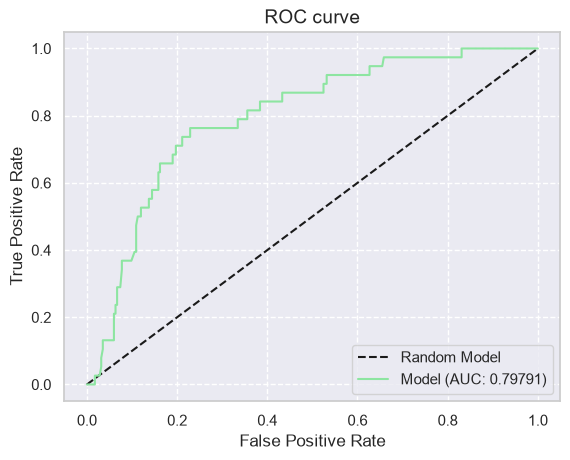

In [69]:
plot_auc_roc(Y_test,Y_test_pred)

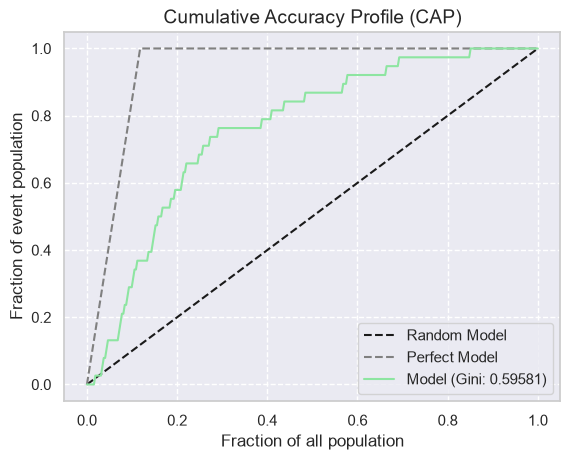

In [70]:
plot_cap(Y_test,Y_test_pred)

In [71]:
score = scorecard.score(X)
print("Min Score: ", score.min().round(2))
print("Max Score: ",score.max().round(2))
print("Mean Score : ",score.mean().round(2))

Min Score:  326.52
Max Score:  822.95
Mean Score :  542.1


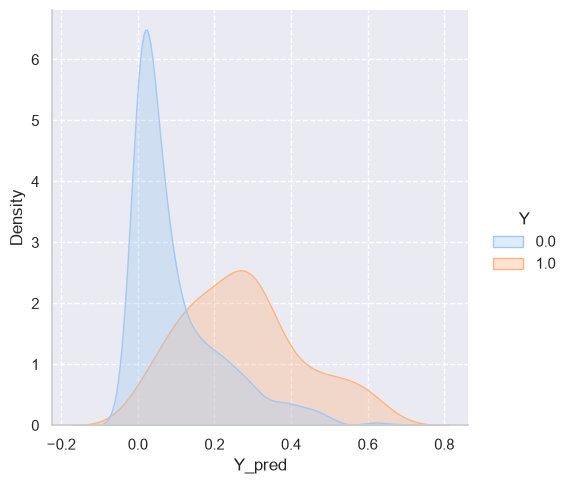

In [73]:
data_score=pd.DataFrame(np.transpose([Y_pred,Y]), columns=['Y_pred','Y'])
sns.displot(data=data_score, x='Y_pred', label="event", hue='Y', alpha=0.35,kind="kde", fill=True, common_norm=False)
plt.show()

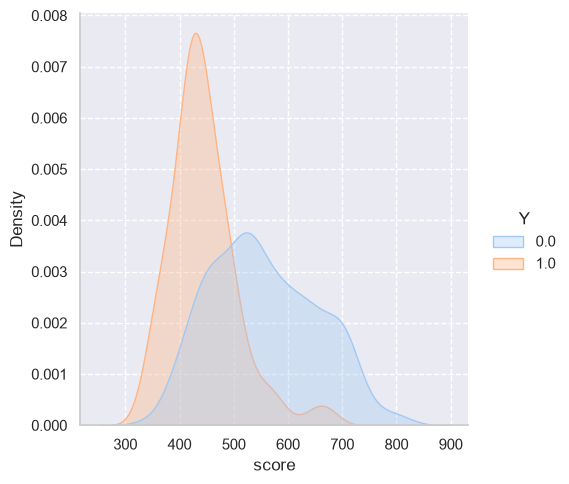

In [74]:
data_score=pd.DataFrame(np.transpose([score,Y]), columns=['score','Y'])
sns.displot(data=data_score, x='score', label="event", hue='Y', alpha=0.35,kind="kde", fill=True, common_norm=False)
plt.show()

In [75]:
c=np.arange(0,1,0.01)

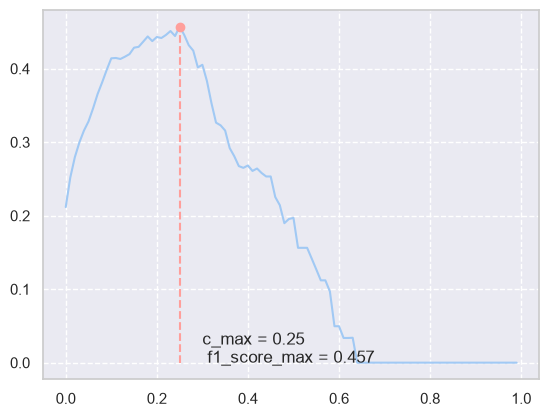

In [78]:
f1_score_ = [f1_score(df_train["default"],np.multiply(Y_pred>c_,1)) for c_ in c]
c_max = c[np.argmax(f1_score_)]

plt.plot(c,f1_score_)
plt.stem(c_max, np.max(f1_score_),linefmt='r--', markerfmt='ro', basefmt='r--')
plt.text(c_max+0.05, 0, "c_max = "+str(c_max.round(2))+"\n f1_score_max = "+str(np.max(f1_score_).round(3)))
plt.show()

c_maxF1=c_max

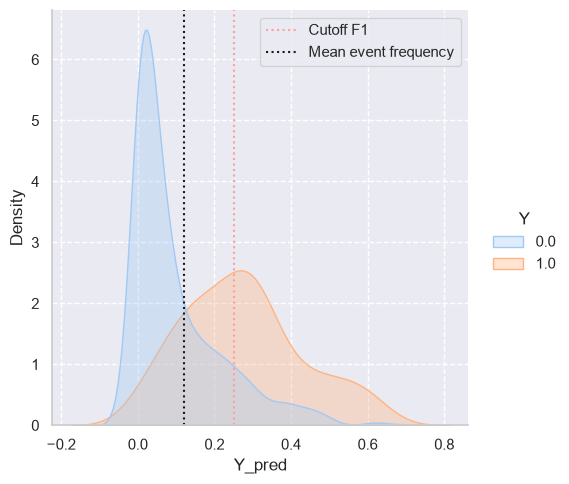

In [81]:
data_score=pd.DataFrame(np.transpose([Y_pred,Y]), columns=['Y_pred','Y'])
sns.displot(data=data_score, x='Y_pred', hue='Y', alpha=0.35,kind="kde", fill=True, common_norm=False)
plt.axvline(c_maxF1, color='r', linestyle=":", label="Cutoff F1")
plt.axvline(round(Y.mean(),2), color='k', linestyle=":", label="Mean event frequency")
plt.legend()

In [84]:
Prob_Cutoff=c_maxF1
print(' Cutoff selected:', Prob_Cutoff,'\n',
      'Mean event frequency (y=1):', round(Y.mean(),2), '\n',
      'Prob max f1:', c_maxF1, '\n',
      'Max F1 score', np.max(f1_score_).round(3))

 Cutoff selected: 0.25 
 Mean event frequency (y=1): 0.12 
 Prob max f1: 0.25 
 Max F1 score 0.457


In [90]:
X_new = new_clients.drop(columns=['default','Prob_without_rejected','y_without_rejected'])
Y_new_pred=scorecard.predict_proba(X_new)[:,1]
new_clients["Prob_with_rejected"]=np.multiply(Y_new_pred,1)
new_clients["y_with_rejected"]=np.multiply(Y_new_pred>Prob_Cutoff,1)

print("First model (odds without rejected):",new_clients["Prob_without_rejected"].mean().round(3))
print("Second model (odds with rejected)):",new_clients["Prob_with_rejected"].mean().round(3))


First model (odds without rejected): 0.117
Second model (odds with rejected)): 0.145


In [94]:
X_rejected = rejected.drop(columns=['default']) 
Y_rejected_pred_pred=scorecard.predict_proba(X_rejected)[:,1] 
rejected["default_2"]=np.multiply(Y_rejected_pred>Prob_Cutoff,1)  

rejected["default_2"].value_counts(normalize=True)

default_2
0    0.962199
1    0.037801
Name: proportion, dtype: float64

# 6. Results 

In [98]:
new_clients

,ID,Cardhldr,default,Age,Income,Exp_Inc,Avgexp,Ownrent,Selfempl,Depndt,Inc_per,Cur_add,Major,Active,Prob_without_rejected,y_without_rejected,Prob_with_rejected,y_with_rejected,Score_with_rejected
1285,1286,NaN,NaN,27.000000,2.6750,0.0,0.0,1.0,0.0,0.0,2.675000,135.0,1.0,0.0,0.017088,0,0.012977,0,624.207906
1286,1287,NaN,NaN,27.583330,5.5000,0.0,0.0,0.0,1.0,0.0,5.500000,72.0,1.0,11.0,0.178656,1,0.251898,1,437.061503
1287,1288,NaN,NaN,31.250000,5.0000,0.0,0.0,1.0,0.0,2.0,1.666667,12.0,1.0,12.0,0.205682,1,0.231597,0,443.455602
1288,1289,NaN,NaN,25.250000,2.8800,0.0,0.0,0.0,0.0,0.0,2.880000,7.0,1.0,0.0,0.007686,0,0.005331,0,675.991673
1289,1290,NaN,NaN,30.000000,1.8500,0.0,0.0,0.0,0.0,0.0,1.850000,60.0,1.0,12.0,0.326784,1,0.455019,1,384.656981
1290,1291,NaN,NaN,35.500000,5.5000,0.0,0.0,0.0,0.0,0.0,5.500000,36.0,1.0,2.0,0.023240,0,0.054058,0,539.412838
1291,1292,NaN,NaN,33.250000,3.6000,0.0,0.0,0.0,0.0,3.0,0.900000,16.0,1.0,9.0,0.118916,0,0.137608,0,480.156869
1292,1293,NaN,NaN,39.000000,3.5000,0.0,0.0,1.0,0.0,2.0,1.166667,113.0,0.0,13.0,0.266312,1,0.326333,1,416.073309
1293,1294,NaN,NaN,40.750000,8.0000,0.0,0.0,1.0,0.0,2.0,2.666667,38.0,1.0,0.0,0.019379,0,0.027157,0,580.757955
1294,1295,NaN,NaN,63.166670,5.5000,0.0,0.0,1.0,0.0,1.0,2.750000,192.0,1.0,15.0,0.385158,1,0.503850,1,373.356969
